<a href="https://colab.research.google.com/github/tatyanalitvin/python_for_ds_tasks/blob/dev/HW_2_1_%D0%A4%D1%83%D0%BD%D0%BA%D1%86%D1%96%D1%97_%D1%96_%D0%BF%D0%BE%D1%85%D1%96%D0%B4%D0%BD%D1%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import matplotlib.pyplot as plt
import sympy as sp
import numpy as np
from IPython.display import display, Math

print(sp.__version__)

1.14.0


### Домашні завдання на відпрацювання поняття функції та її похідної

1. Задана функція залежності оцінки від кількості годин, витрачених на навчання: $ f(x) = 10x - 5 $.
  1. З допомогою Python обчисліть похідну цієї функції.
  2. Використовуйте бібліотеку `matplotlib` для побудови графіків функції та її похідної в діапазоні значень від 0 до 10 годин. Проаналізуйте, як зміна кількості годин вивчення впливає на оцінку.



In [72]:
# sp.diff?
# sp.lambdify?
# np.linspace?
# np.full_like?

In [82]:
# Helpers
def calculate_diff(f_x, x):
  df_dx = sp.diff(f_x, x)
  display(sp.Eq(sp.Symbol('f(x)'), f_x))
  display(sp.Eq(sp.Derivative(sp.Symbol('f(x)'), x), df_dx))
  return df_dx

def plot_function_and_derivative(
      f_x,
      df_dx,
      x,
      x_range=(0, 10), # tuple of (min, max) for x-axis
      num_points=100 # number of points to plot
    ):

    # конвертація SymPy expression в numpy еквівалент, щоб створити точки
    f_x_numpy = sp.lambdify(x, f_x, 'numpy')
    df_dx_numpy = sp.lambdify(x, df_dx, 'numpy')

    # рівномірні числа (num_points штук) на інтервалі min, max
    x_vals = np.linspace(x_range[0], x_range[1], num_points)
    y_vals_f_x = f_x_numpy(x_vals)
    y_vals_df_dx = df_dx_numpy(x_vals)

    # якщо df(x)/dx - константа
    if np.isscalar(y_vals_df_dx):
        y_vals_df_dx = np.full_like(x_vals, y_vals_df_dx) # y_vals_df_dx = 10, -> масив у форматі x_vals [10, 10, 10...10]

    plt.figure(figsize=(10, 6))
    plt.plot(
        x_vals,
        y_vals_f_x,
        label=f'$f(x) = {sp.latex(f_x)}$'
        )
    plt.plot(
        x_vals,
        y_vals_df_dx,
        label=f"$f'(x) = {sp.latex(df_dx)}$",
        linewidth=2,
        linestyle='--')
    plt.grid(True, alpha=0.3)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.title("F(x) and dF(x)/d(x)", fontsize=14)
    plt.legend(fontsize=11)
    plt.show()

In [56]:
x = sp.symbols('x')

Eq(f(x), 10*x - 5)

Eq(Derivative(f(x), x), 10)

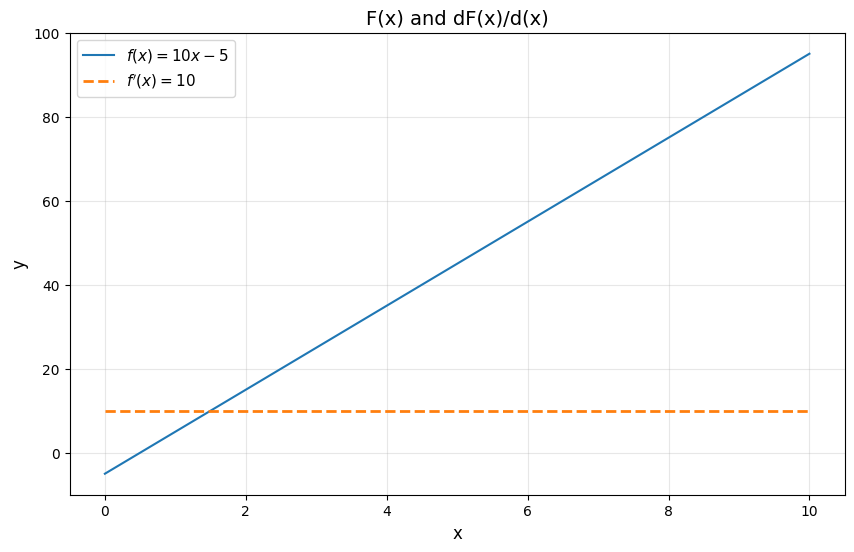

In [83]:
f_x = 10 * x - 5
df_dx = calculate_diff(f_x, x)
x_range = (0, 10)
plot_function_and_derivative(
      f_x,
      df_dx,
      x,
      x_range
    )

Швидкість зміни оцінки постійна (похідна = 10 <- константа). За кожну годину навчання оцінка зростає на 10, якщо ж витратити 0 годин, то оцінка буде -5.

2. Використовуючи Python і `SymPy`, обчисліть похідні для функцій $ f(x) = \sin(x) $ та $ f(x) = \ln(x) $. Зобразіть ці функції та їхні похідні за допомогою `matplotlib`.



Eq(f(x), sin(x))

Eq(Derivative(f(x), x), cos(x))

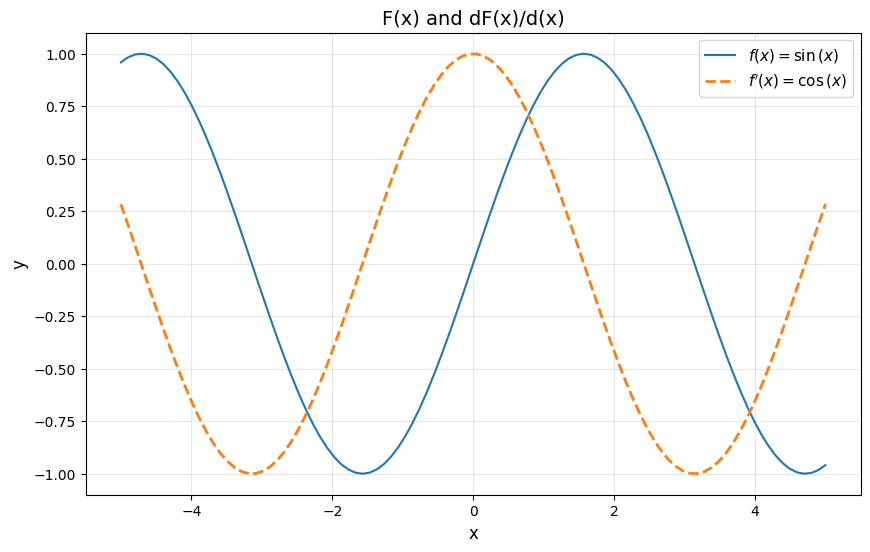

In [79]:
f_x = sp.sin(x)
df_dx = calculate_diff(f_x, x)
x_range = (-5, 5)
plot_function_and_derivative(
      f_x,
      df_dx,
      x,
      x_range
    )

Eq(f(x), log(x))

Eq(Derivative(f(x), x), 1/x)

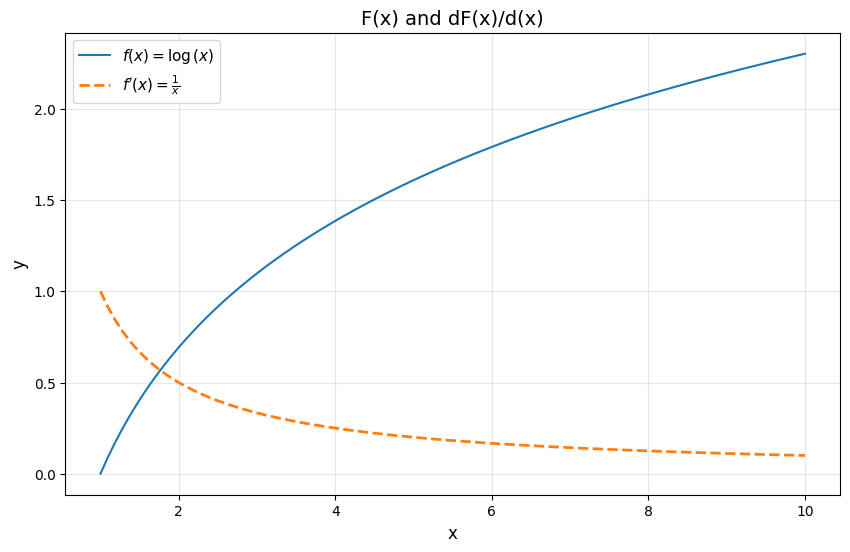

In [78]:
f_x = sp.ln(x)
df_dx = calculate_diff(f_x, x)
x_range = (1, 10)
plot_function_and_derivative(
      f_x,
      df_dx,
      x,
      x_range
    )


3. Загальні витрати компанії від обсягу виробництва задані функцією $ f(x) = x^2 - 5x + 1 $, де $ x $ — кількість вироблених одиниць. Обчисліть похідну цієї функції з допомогою SymPy та візуалізуйте значення функції і її похідної на відрізку від 0 до 100.

Eq(f(x), x**2 - 5*x + 1)

Eq(Derivative(f(x), x), 2*x - 5)

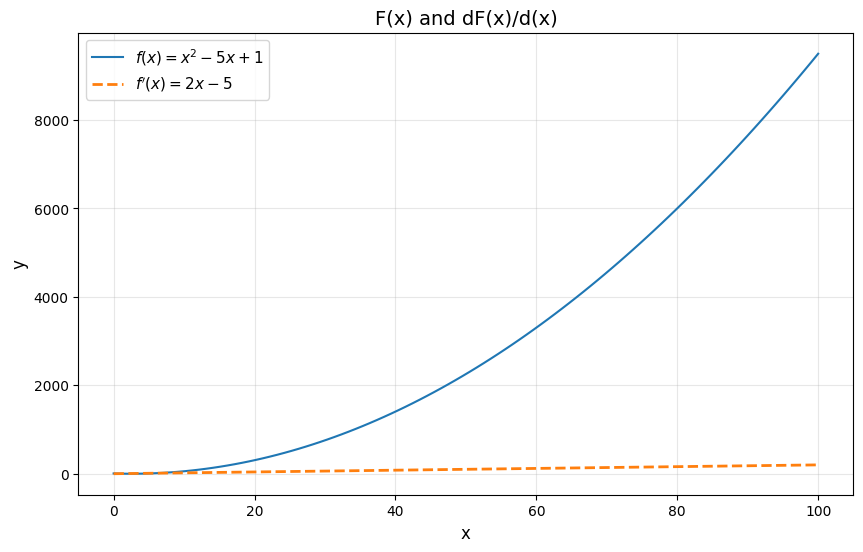

In [77]:
f_x = x**2 - 5*x + 1
df_dx = calculate_diff(f_x, x)
x_range = (0, 100)
plot_function_and_derivative(
      f_x,
      df_dx,
      x,
      x_range
    )